In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('../data/Nat_Gas.csv')
df.head()

,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


In [ ]:
df['Dates'] = pd.to_datetime(df['Dates'])

C:\Users\vinay\AppData\Local\Temp\ipykernel_10732\2452315616.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


In [ ]:
df = df.sort_values('Dates')

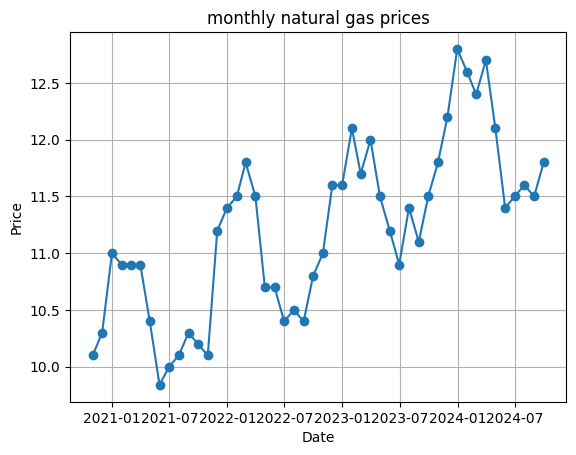

<Figure size 1000x400 with 0 Axes>

In [ ]:
plt.plot(df['Dates'], df['Prices'], marker = 'o')
plt.title('monthly natural gas prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.figure(figsize=(10, 4))
plt.show()

***Modeling The Trend***

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

In [ ]:
#converting dates to numeric values
df['Days'] = (df['Dates'] - df['Dates'].min()).dt.days
x = df[['Days']]
y = df['Prices']

model = LinearRegression()
model.fit(x, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


***Create Predection Function***

In [ ]:
from datetime import datetime

def predict_price(input_date_str):
  input_date = pd.to_datetime(input_date_str)
  days = (input_date - df['Dates'].min()).days
  return model.predict([[days]])[0]

In [ ]:
print(predict_price('2025-06-30'))

12.474923364640937


c:\Users\vinay\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


***taking input from user and providing the predectecd price ***

In [ ]:
'''input_user = input('eneter the date to know the predicted price:')
print(predict_price(input_user))'''

"input_user = input('eneter the date to know the predicted price:')\nprint(predict_price(input_user))"

In [ ]:
'''future_dates = pd.date_range(start="2024-10-31", end="2025-09-30", freq="M")
future_days = (future_dates - df['Dates'].min()).days
future_preds = model.predict(future_days.values.reshape(-1, 1))

plt.figure(figsize=(12,5))
plt.plot(df['Dates'], df['Prices'], label="Historical")
plt.plot(future_dates, future_preds, label="Predicted", linestyle="--")
plt.legend()
plt.show()'''

'future_dates = pd.date_range(start="2024-10-31", end="2025-09-30", freq="M")\nfuture_days = (future_dates - df[\'Dates\'].min()).days\nfuture_preds = model.predict(future_days.values.reshape(-1, 1))\n\nplt.figure(figsize=(12,5))\nplt.plot(df[\'Dates\'], df[\'Prices\'], label="Historical")\nplt.plot(future_dates, future_preds, label="Predicted", linestyle="--")\nplt.legend()\nplt.show()'